**Environment Setup**

In [ ]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

import jax
import jax.numpy as jnp
from jax import random
from scipy.stats import f

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
utility_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/Plot_Utility.py'
with open(utility_link) as utility_file: exec(utility_file.read())

**Necessary Parameter Setup**

In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [ ]:
# --------------------------------------------------
# Randomly select dimensions for different variances
# --------------------------------------------------

base_key = random.PRNGKey(42)

# Split keys so the selections are reproducible
key_1000, key_100 = random.split(base_key)

# Randomly choose 10 distinct dimensions for variance 1000
selected_1000 = random.choice(
    key_1000,
    100,
    shape=(10,),
    replace=False
)

# Choose another 10 distinct dimensions for variance 100
# while excluding the first 10
remaining = jnp.setdiff1d(
    jnp.arange(100),
    selected_1000
)

selected_100 = random.choice(
    key_100,
    remaining,
    shape=(10,),
    replace=False
)

In [ ]:
save_dir = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment"

### **Plots**

In [ ]:
# MSE vs nested Rhat:
R_hat_c_path = f"{save_dir}/Controll_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_hat_c_path)
print("No Transform Data Loaded!")

R_hat_c_path = f"{save_dir}/AR_Rhat_c.pkl"
AR_R_Hat_c_df = pd.read_pickle(R_hat_c_path)
print("Transformed Data Loaded!")

No Transform Data Loaded!
Transformed Data Loaded!


In [ ]:
HighlightIndex1 = selected_1000.tolist()
HighlightIndex2 = selected_100.tolist()
Warmup_List = [10, 20, 30, 40,50, 100, 200, 500, 1000]

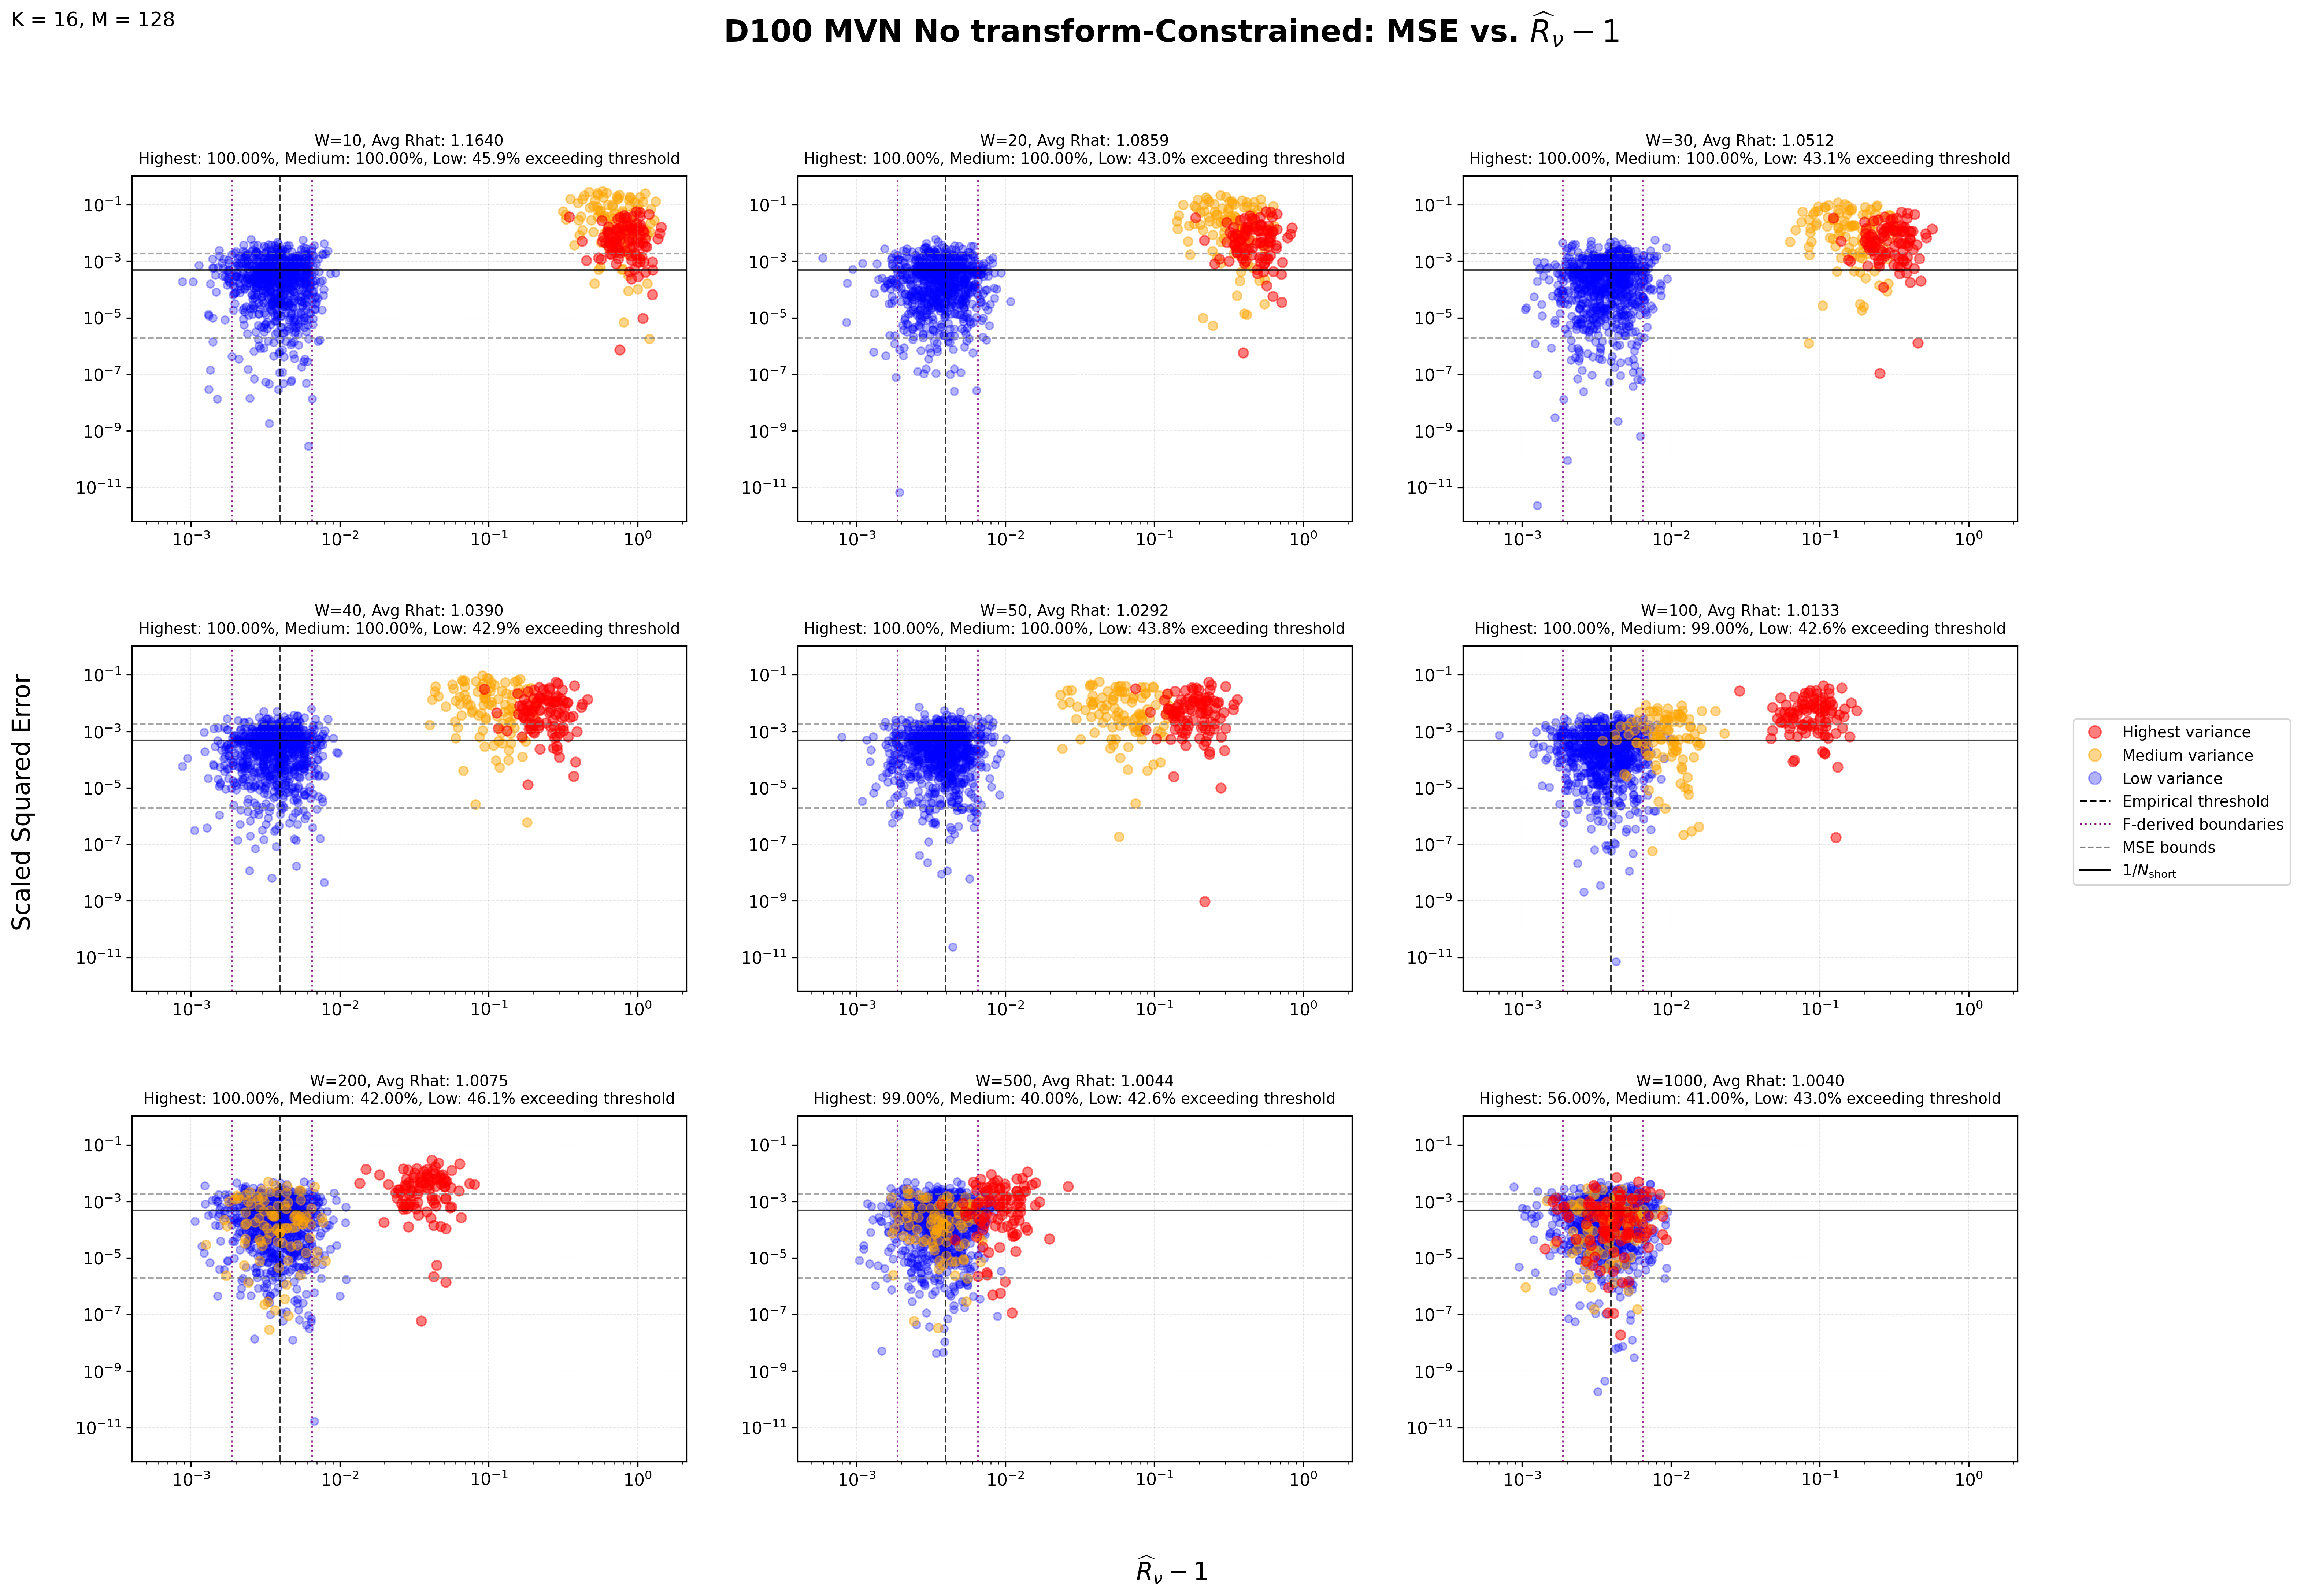

In [ ]:
plot_mse_vs_rhat_9("D100 MVN No transform-Constrained",
                   R_Hat_c_df,
                   Warmup_List,
                   HighlightIndex1,
                   HighlightIndex2,
                   bound,
                   threshold,
                   num_chains_short,
                   num_super_chains)

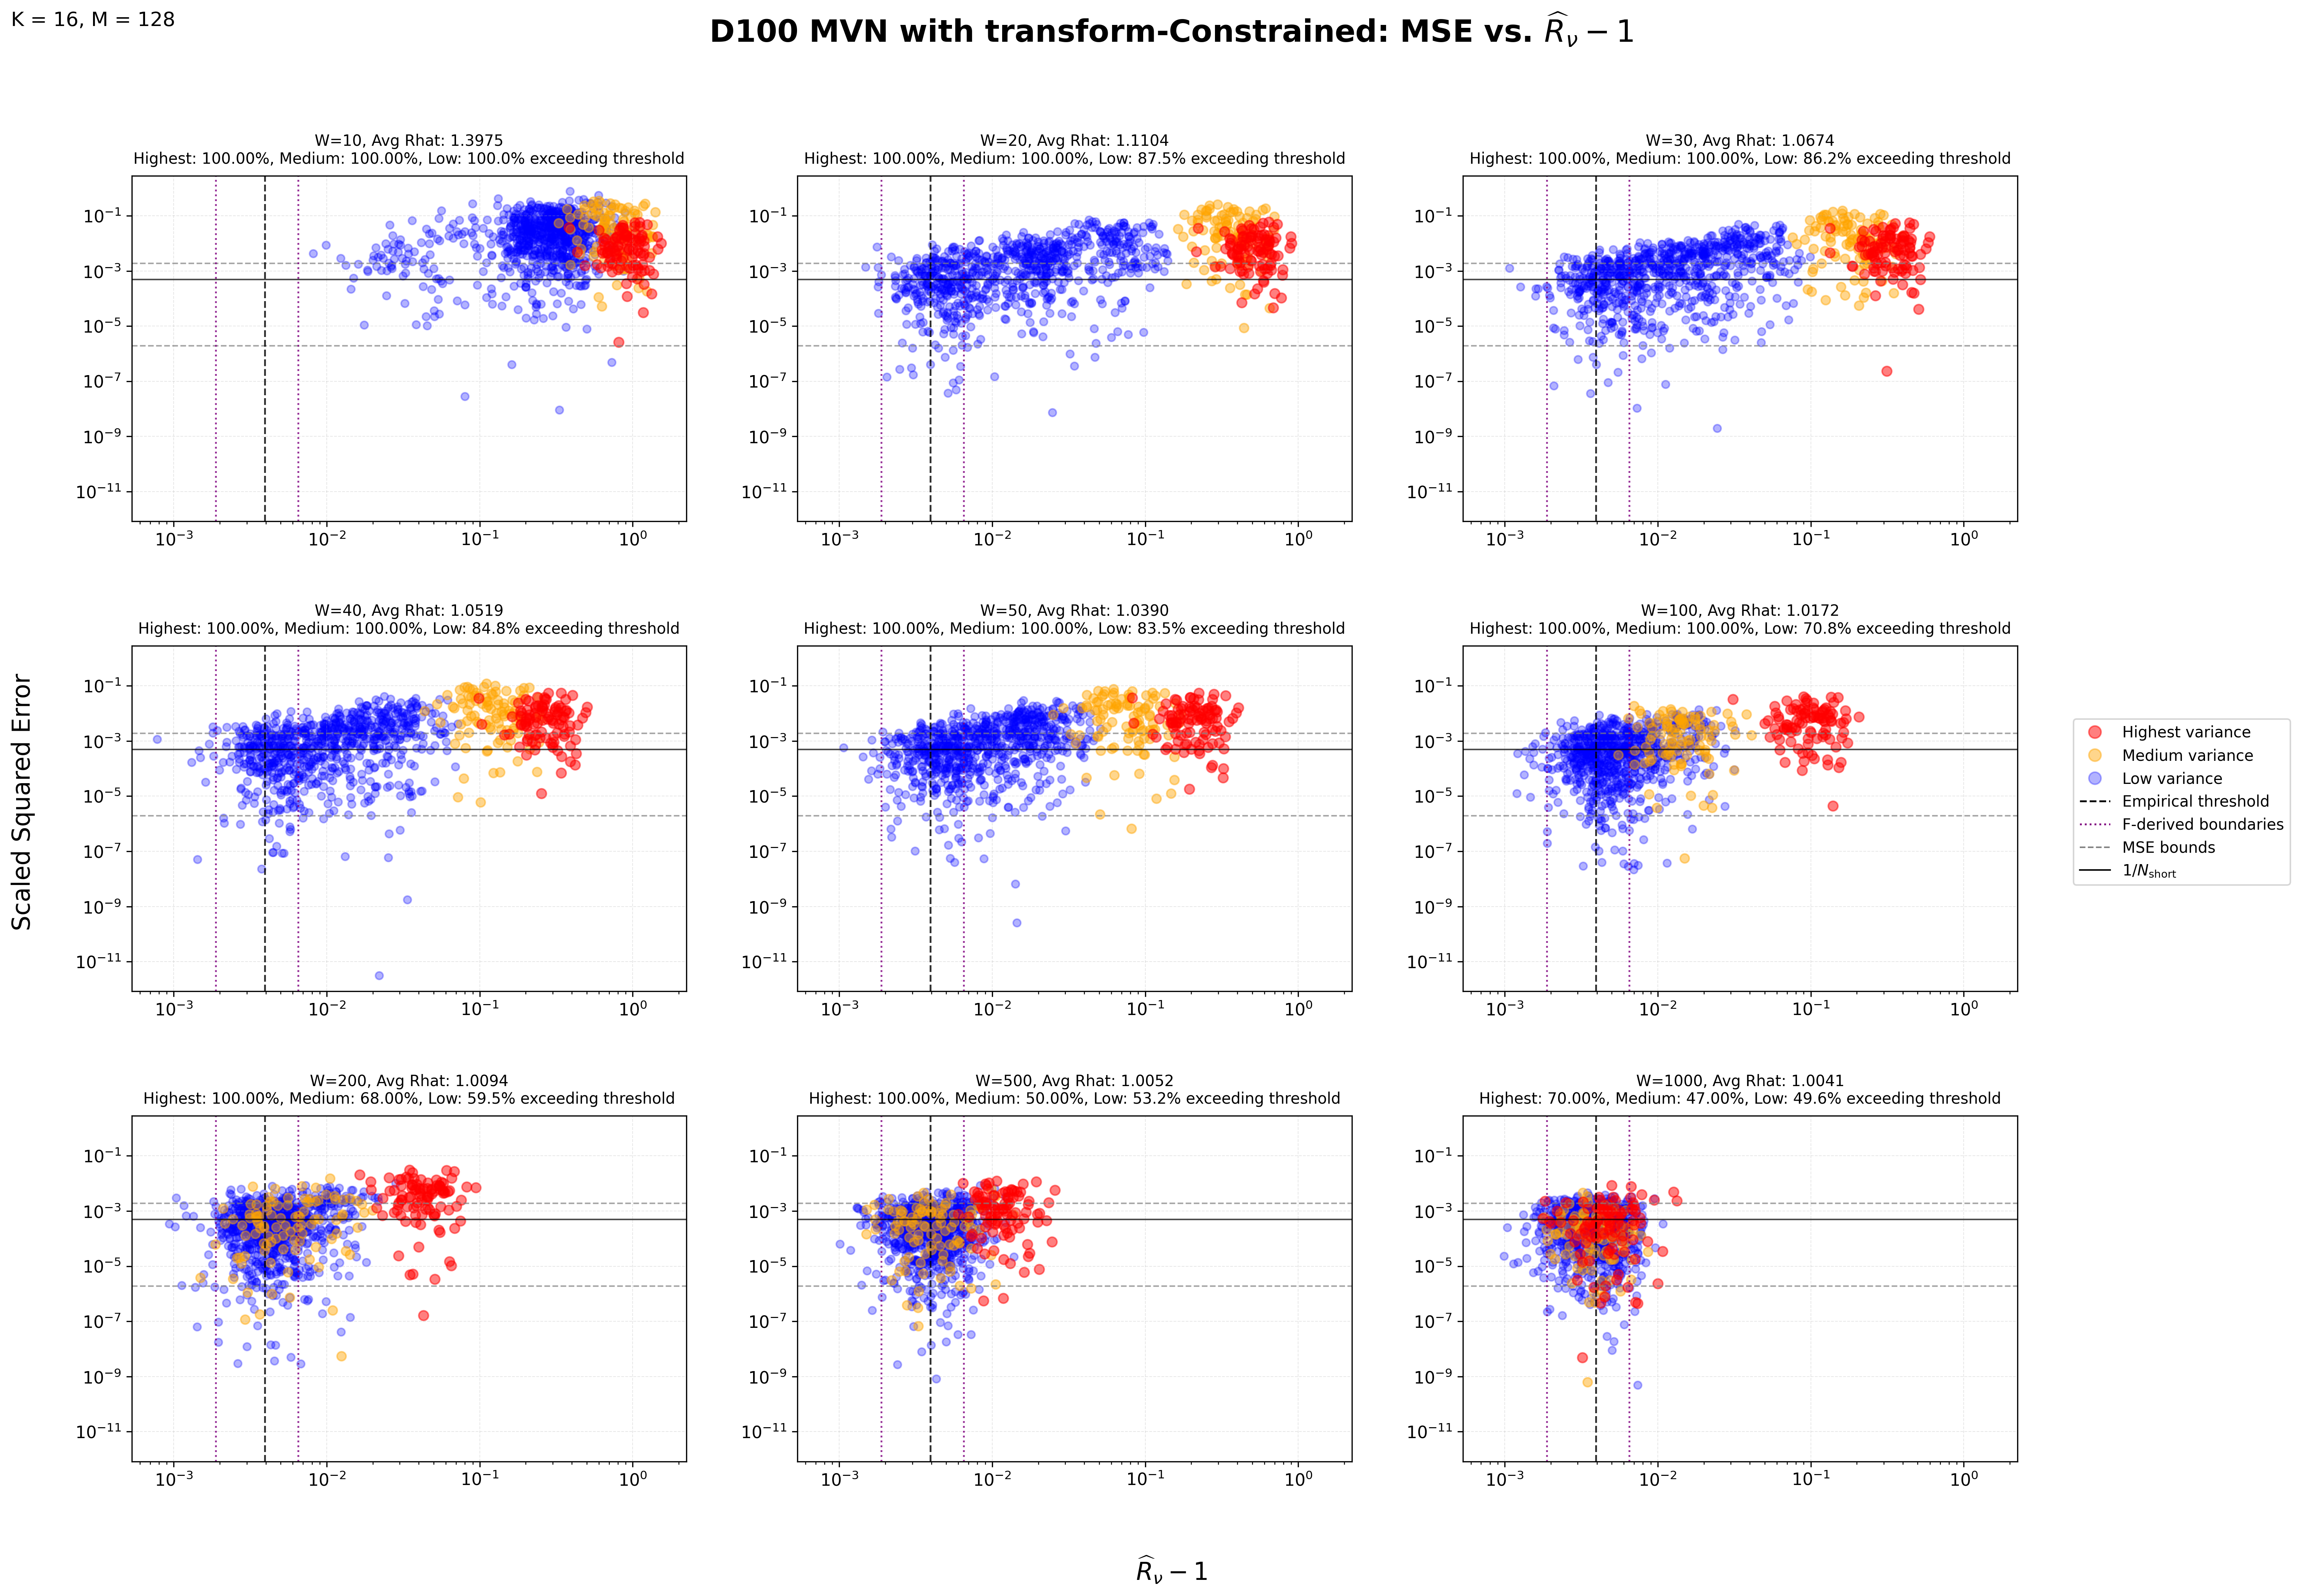

In [ ]:
plot_mse_vs_rhat_9("D100 MVN with transform-Constrained",
                   AR_R_Hat_c_df,
                   Warmup_List,
                   HighlightIndex1,
                   HighlightIndex2,
                   bound,
                   threshold,
                   num_chains_short,
                   num_super_chains)